# Pairs Trading

The purpose of this project is to:
   1) Identify co-integrated pairs across different sectors
   2) Develop tradeable objects/strategies based on these pairs
   3) Test these strategies on future data

## Step 1) Data Exploration

We will try to identify co-integrated pairs in the following sectors:
- Commodities
    - Gold (GLD)
    - Silver (SLV)
    - Copper (CPER)
- Consumer Beverages
    - Coca-Cola (KO)
    - PepsiCo (PEP)
    - Keurig DrPepper (KDP)
- Banks
    - JPMorgan (JPM)
    - Goldman Sachs (GS)
    - Morgan Stanley (MS)
    - Bank of America (BAC)
    - Citi (C)

### Commodities

In [35]:
import importlib
import data_tools
importlib.reload(data_tools)

<module 'data_tools' from '/Users/suhaib/Documents/Pairs Trading/data_tools.py'>

In [49]:
import yfinance as yf
import numpy as np
import pandas as pd
import warnings
from data_tools import cointegration_test
warnings.filterwarnings('ignore')

tickers = ['GLD', 'SLV', 'CPER', 'USO', 'UNG', 'PPLT', 'BNO', 'CORN', 'WEAT', 'SOYB']
prices = yf.download(tickers, start='2013-01-01', end='2023-01-01', auto_adjust=True)['Close']
log_prices = np.log(prices)
#Stack a row of zeros for plotting purposes
log_returns = log_prices.diff().dropna()
log_returns = pd.DataFrame(np.vstack([np.zeros(len(tickers)).reshape(1, len(tickers)), log_returns]))
log_returns.index = log_prices.index
log_returns.columns = log_prices.columns

[*********************100%***********************]  10 of 10 completed


Text(0.5, 1.0, 'Log Returns over Time')

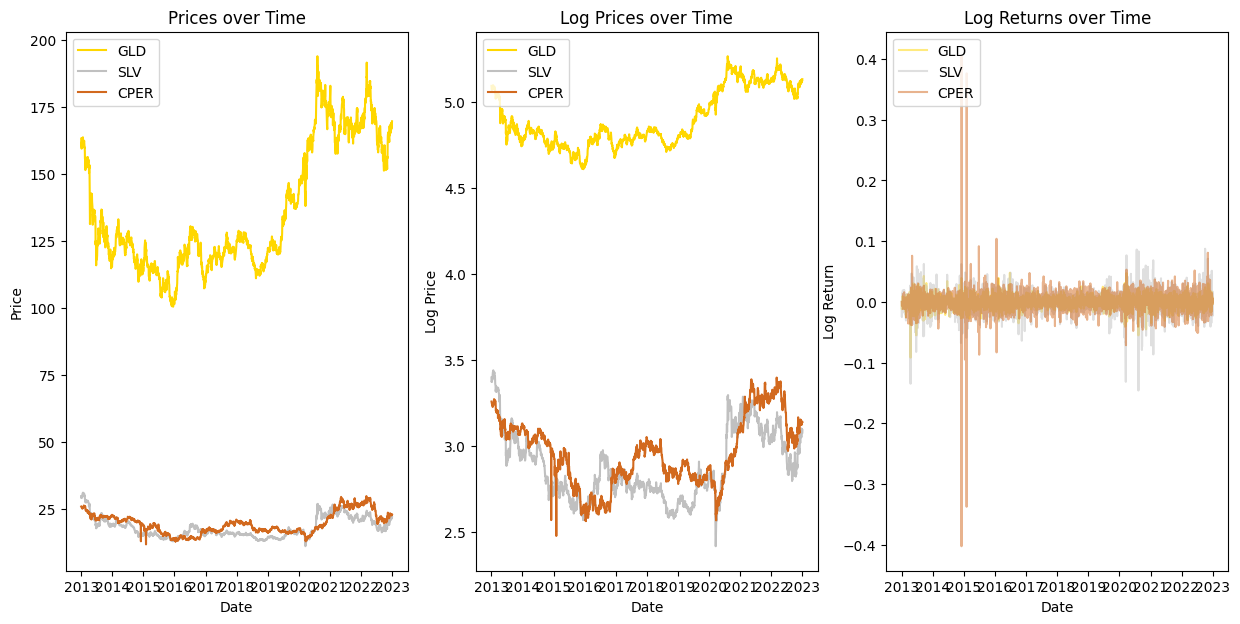

In [37]:
import matplotlib.pyplot as plt

#Exploratory Plots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 7))

#Prices over time
ax1.plot(prices.index, prices['GLD'], label='GLD', color='gold')
ax1.plot(prices.index, prices['SLV'], label='SLV', color='silver')
ax1.plot(prices.index, prices['CPER'], label='CPER', color='chocolate')
ax1.legend(loc='upper left')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')
ax1.set_title('Prices over Time')

#Log prices over time
ax2.plot(log_prices.index, log_prices['GLD'], label='GLD', color='gold')
ax2.plot(log_prices.index, log_prices['SLV'], label='SLV', color='silver')
ax2.plot(log_prices.index, log_prices['CPER'], label='CPER', color='chocolate')
ax2.legend(loc='upper left')
ax2.set_xlabel('Date')
ax2.set_ylabel('Log Price')
ax2.set_title('Log Prices over Time')

#Log returns over time
ax3.plot(log_returns.index, log_returns['GLD'], label='GLD', color='gold', alpha=0.5)
ax3.plot(log_returns.index, log_returns['SLV'], label='SLV', color='silver', alpha=0.5)
ax3.plot(log_returns.index, log_returns['CPER'], label='CPER', color='chocolate', alpha=0.5)
ax3.legend(loc='upper left')
ax3.set_xlabel('Date')
ax3.set_ylabel('Log Return')
ax3.set_title('Log Returns over Time')


#### Testing for Cointegration

Below we check which pairs of industry stocks are cointegrated using the Granger Engle method, which involves 2 steps:
1) Fitting a linear regression on 1 stock from the other (via Sklearn LinearRegression)
2) Testing if the fitted residuals are stationary using the Augmented Dickey Fuller test (via Statsmodels adfuller), using a 95% confidence level
    - If the p_value is less than 0.05, then we can conclude the 2 stocks are cointegrated
    - If the p_value is greater than or equal to 0.05, then we cannot say they are cointegrated

In [50]:
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import adfuller
from itertools import combinations

pairs = list(combinations(tickers, 2))
# for ticker1, ticker2 in [('GLD', 'SLV'), ('GLD', 'CPER'), ('SLV', 'CPER')]:
for ticker1, ticker2 in pairs:
    cointegration_test(ticker1, ticker2, log_prices, verbose=True)



GLD & SLV: Cointegrated! -- p-value: 0.0
GLD & CPER: Cointegrated! -- p-value: 0.02
GLD & USO: Cointegrated! -- p-value: 0.01
GLD & UNG: Cointegrated! -- p-value: 0.01
GLD & PPLT: Cointegrated! -- p-value: 0.01
GLD & BNO: Not Cointegrated... -- p-value: 0.08
GLD & CORN: Cointegrated! -- p-value: 0.02
GLD & WEAT: Cointegrated! -- p-value: 0.01
GLD & SOYB: Not Cointegrated... -- p-value: 0.32
SLV & CPER: Cointegrated! -- p-value: 0.0
SLV & USO: Not Cointegrated... -- p-value: 0.06
SLV & UNG: Not Cointegrated... -- p-value: 0.16
SLV & PPLT: Not Cointegrated... -- p-value: 0.13
SLV & BNO: Not Cointegrated... -- p-value: 0.12
SLV & CORN: Not Cointegrated... -- p-value: 0.08
SLV & WEAT: Not Cointegrated... -- p-value: 0.08
SLV & SOYB: Not Cointegrated... -- p-value: 0.09
CPER & USO: Not Cointegrated... -- p-value: 0.11
CPER & UNG: Not Cointegrated... -- p-value: 0.19
CPER & PPLT: Cointegrated! -- p-value: 0.03
CPER & BNO: Not Cointegrated... -- p-value: 0.07
CPER & CORN: Not Cointegrated... 

#### Commodities Reflection

We can see that all 3 commodities are cointegrated with each other. This is expected for Gold & Silver, since they are both seen as being driven by the FED's interest rate levels and inflation. Their cointegration with Copper is surprising, since Copper is seen as an indicator on the performance of industrial companies where it is used as a key tool.

For the remainder of this project, we will focus on the Gold & Silver pair from the commodities sector, due to its economic and mathematical support for cointegration.

## Consumer Beverage

In [39]:
import yfinance as yf
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

prices = yf.download(['KO', 'PEP', 'KDP'], start='2013-01-01', end='2023-01-01', auto_adjust=True)['Close']
log_prices = np.log(prices)
#Stack a row of zeros for plotting purposes
log_returns = log_prices.diff().dropna()
log_returns = pd.DataFrame(np.vstack([np.zeros(3).reshape(1, 3), log_returns]))
log_returns.index = log_prices.index
log_returns.columns = log_prices.columns

[*********************100%***********************]  3 of 3 completed


Text(0.5, 1.0, 'Log Returns over Time')

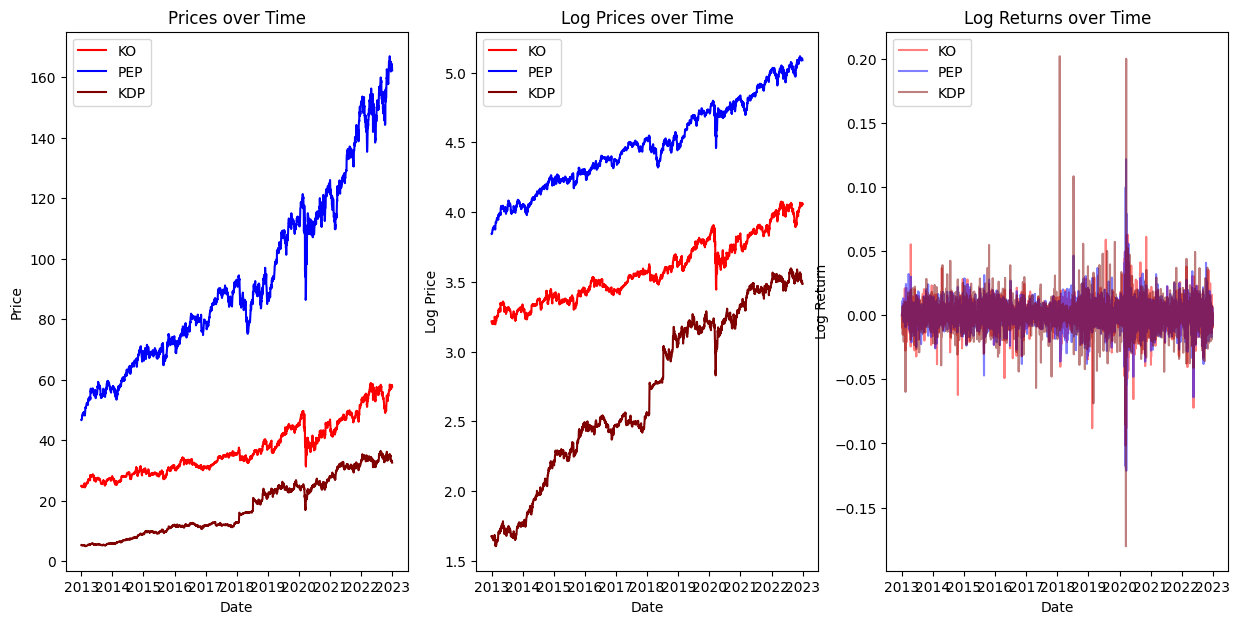

In [40]:
import matplotlib.pyplot as plt

#Exploratory Plots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 7))

#Prices over time
ax1.plot(prices.index, prices['KO'], label='KO', color='red')
ax1.plot(prices.index, prices['PEP'], label='PEP', color='blue')
ax1.plot(prices.index, prices['KDP'], label='KDP', color='maroon')
ax1.legend(loc='upper left')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')
ax1.set_title('Prices over Time')

#Log prices over time
ax2.plot(log_prices.index, log_prices['KO'], label='KO', color='red')
ax2.plot(log_prices.index, log_prices['PEP'], label='PEP', color='blue')
ax2.plot(log_prices.index, log_prices['KDP'], label='KDP', color='maroon')
ax2.legend(loc='upper left')
ax2.set_xlabel('Date')
ax2.set_ylabel('Log Price')
ax2.set_title('Log Prices over Time')

#Log returns over time
ax3.plot(log_returns.index, log_returns['KO'], label='KO', color='red', alpha=0.5)
ax3.plot(log_returns.index, log_returns['PEP'], label='PEP', color='blue', alpha=0.5)
ax3.plot(log_returns.index, log_returns['KDP'], label='KDP', color='maroon', alpha=0.5)
ax3.legend(loc='upper left')
ax3.set_xlabel('Date')
ax3.set_ylabel('Log Return')
ax3.set_title('Log Returns over Time')


In [41]:
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import adfuller

for ticker1, ticker2 in [('KO', 'PEP'), ('KO', 'KDP'), ('PEP', 'KDP')]:

    cointegration_test(ticker1, ticker2, log_prices, verbose=True)



KO & PEP: Cointegrated! -- p-value: 0.0
KO & KDP: Cointegrated! -- p-value: 0.01
PEP & KDP: Cointegrated! -- p-value: 0.05


#### Consumer Beverage Reflection

We can see that all 3 consumer beverage companies are cointegrated with each other. We can see the pair with the (relative) least strength for cointegration is PepsiCo and KeurigDrPepper, which may be a result of these companies projects in non-beverage products. For the remainder of this project, we will focus on the Coca-Cola & Pepsi consumer beverage pair, as this was presented as an example in my lecture notes from class.


## Banks

In [42]:
import yfinance as yf
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

prices = yf.download(['JPM', 'GS', 'MS', 'BAC', 'C'], start='2013-01-01', end='2023-01-01', auto_adjust=True)['Close']
log_prices = np.log(prices)
#Stack a row of zeros for plotting purposes
log_returns = log_prices.diff().dropna()
log_returns = pd.DataFrame(np.vstack([np.zeros(5).reshape(1, 5), log_returns]))
log_returns.index = log_prices.index
log_returns.columns = log_prices.columns

[*********************100%***********************]  5 of 5 completed


Text(0.5, 1.0, 'Log Returns over Time')

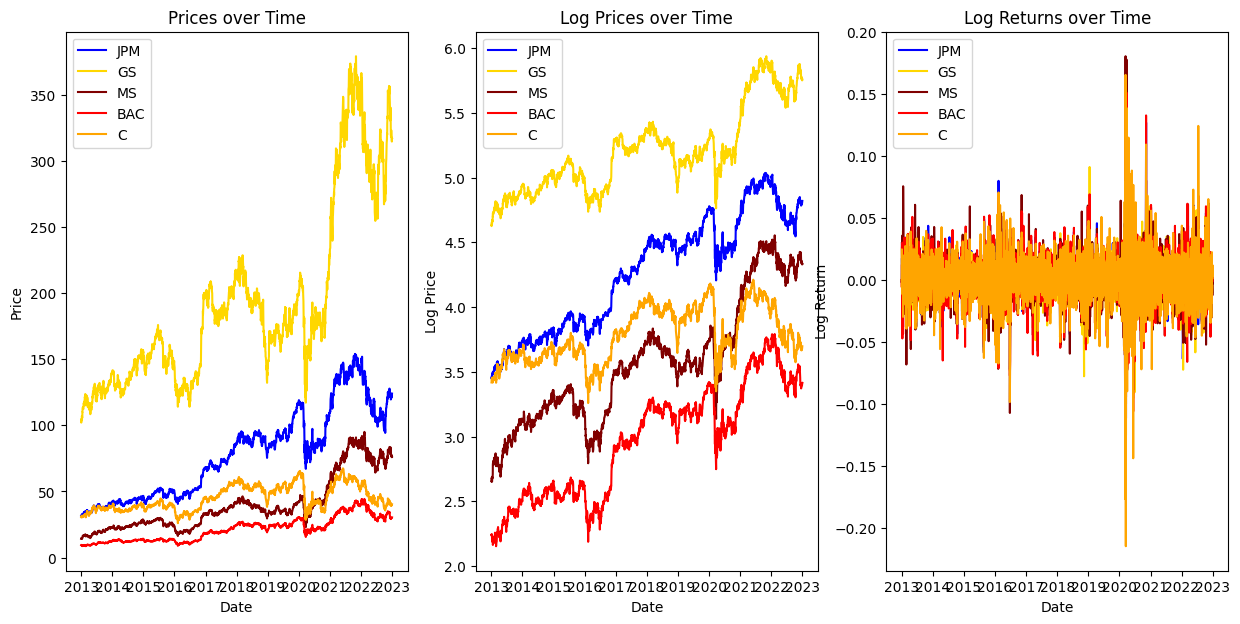

In [43]:
import matplotlib.pyplot as plt

#Exploratory Plots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 7))

#Prices over time
ax1.plot(prices.index, prices['JPM'], label='JPM', color='blue')
ax1.plot(prices.index, prices['GS'], label='GS', color='gold')
ax1.plot(prices.index, prices['MS'], label='MS', color='maroon')
ax1.plot(prices.index, prices['BAC'], label='BAC', color='red')
ax1.plot(prices.index, prices['C'], label='C', color='orange')
ax1.legend(loc='upper left')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')
ax1.set_title('Prices over Time')

#Log prices over time
ax2.plot(log_prices.index, log_prices['JPM'], label='JPM', color='blue')
ax2.plot(log_prices.index, log_prices['GS'], label='GS', color='gold')
ax2.plot(log_prices.index, log_prices['MS'], label='MS', color='maroon')
ax2.plot(log_prices.index, log_prices['BAC'], label='BAC', color='red')
ax2.plot(log_prices.index, log_prices['C'], label='C', color='orange')
ax2.legend(loc='upper left')
ax2.set_xlabel('Date')
ax2.set_ylabel('Log Price')
ax2.set_title('Log Prices over Time')

#Log returns over time
ax3.plot(log_returns.index, log_returns['JPM'], label='JPM', color='blue')
ax3.plot(log_returns.index, log_returns['GS'], label='GS', color='gold')
ax3.plot(log_returns.index, log_returns['MS'], label='MS', color='maroon')
ax3.plot(log_returns.index, log_returns['BAC'], label='BAC', color='red')
ax3.plot(log_returns.index, log_returns['C'], label='C', color='orange')
ax3.legend(loc='upper left')
ax3.set_xlabel('Date')
ax3.set_ylabel('Log Return')
ax3.set_title('Log Returns over Time')


In [44]:
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import adfuller

for ticker1, ticker2 in [('JPM', 'GS'), ('JPM', 'MS'), ('JPM', 'BAC'), ('JPM', 'C'),
                         ('GS', 'MS'), ('GS', 'BAC'), ('GS', 'C'),
                         ('MS', 'BAC'), ('MS', 'C'),
                         ('BAC', 'C')]:

    cointegration_test(ticker1, ticker2, log_prices, verbose=True)



JPM & GS: Not Cointegrated... -- p-value: 0.11
JPM & MS: Not Cointegrated... -- p-value: 0.15
JPM & BAC: Cointegrated! -- p-value: 0.0
JPM & C: Cointegrated! -- p-value: 0.0
GS & MS: Cointegrated! -- p-value: 0.0
GS & BAC: Not Cointegrated... -- p-value: 0.14
GS & C: Cointegrated! -- p-value: 0.03
MS & BAC: Not Cointegrated... -- p-value: 0.08
MS & C: Cointegrated! -- p-value: 0.01
BAC & C: Cointegrated! -- p-value: 0.0


#### Banks Reflection

We can see that unlike the Commodities and Consumer Beverage sectors, not all of the banks are cointegrated with each other. This may be a result of the size of these firms; they will have many sources of revenue and expenses. For the remainder of this project, we will focus on the pair Bank of America & Citi Bank.


## Cross-Sector

While we expect from financial intuition that stocks in the same sector are more likely to be cointegrated together, it may be interesting to see if we can find any cross-sector cointegrations. Wihle the financial intuition may not be as obvious, maybe the 2 stocks are mathematically cointegrated?

In [45]:
import yfinance as yf
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

prices = yf.download(['GLD', 'SLV', 'CPER', 'KO', 'PEP', 'KDP', 'JPM', 'GS', 'MS', 'BAC', 'C'], start='2013-01-01', end='2023-01-01', auto_adjust=True)['Close']
log_prices = np.log(prices)
#Stack a row of zeros for plotting purposes
log_returns = log_prices.diff().dropna()
log_returns = pd.DataFrame(np.vstack([np.zeros(11).reshape(1, 11), log_returns]))
log_returns.index = log_prices.index
log_returns.columns = log_prices.columns

[*********************100%***********************]  11 of 11 completed


In [46]:
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import adfuller
from itertools import combinations

comm_tickers = [('GLD', 'COMM'), ('SLV', 'COMM'), ('CPER', 'COMM')]
bev_tickers = [('KO', 'BEV'), ('PEP', 'BEV'), ('KDP', 'BEV')]
bank_tickers = [('JPM', 'BANK'), ('GS', 'BANK'), ('MS', 'BANK'), ('BAC', 'BANK'), ('C', 'BANK')]
tickers = comm_tickers + bev_tickers + bank_tickers
pairs = list(combinations(tickers, 2))
for ticker1_results, ticker2_results in pairs:

    ticker1, ticker1_industry = ticker1_results
    ticker2, ticker2_industry = ticker2_results

    if ticker1_industry != ticker2_industry:

        cointegration_test(ticker1, ticker2, log_prices, verbose=True)



GLD & KO: Cointegrated! -- p-value: 0.0
GLD & PEP: Cointegrated! -- p-value: 0.0
GLD & KDP: Cointegrated! -- p-value: 0.0
GLD & JPM: Cointegrated! -- p-value: 0.0
GLD & GS: Cointegrated! -- p-value: 0.0
GLD & MS: Cointegrated! -- p-value: 0.0
GLD & BAC: Cointegrated! -- p-value: 0.0
GLD & C: Cointegrated! -- p-value: 0.0
SLV & KO: Not Cointegrated... -- p-value: 0.24
SLV & PEP: Not Cointegrated... -- p-value: 0.12
SLV & KDP: Not Cointegrated... -- p-value: 0.15
SLV & JPM: Not Cointegrated... -- p-value: 0.08
SLV & GS: Cointegrated! -- p-value: 0.03
SLV & MS: Cointegrated! -- p-value: 0.05
SLV & BAC: Cointegrated! -- p-value: 0.05
SLV & C: Cointegrated! -- p-value: 0.0
CPER & KO: Not Cointegrated... -- p-value: 0.13
CPER & PEP: Not Cointegrated... -- p-value: 0.09
CPER & KDP: Not Cointegrated... -- p-value: 0.09
CPER & JPM: Cointegrated! -- p-value: 0.03
CPER & GS: Cointegrated! -- p-value: 0.01
CPER & MS: Cointegrated! -- p-value: 0.01
CPER & BAC: Cointegrated! -- p-value: 0.02
CPER & 

#### Cross-Sector Reflection

Surprisingly, there are many cross-sector cointegrated pairs! As we continue seeing how these pairs would work in an actual trading strategy, it can be interesting to test out a pair that has mathematical support but no financial support.

For the rest of this project, our Cross-Sector pair will be Keurig DrPepper & JPMorgan Chase.